# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Bima Satriawan | 5054251031 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

In [26]:
df = pd.read_csv("data-selected-columns.csv")

print("Shape:", df.shape)
df.info()

Shape: (569, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   569 non-null    int64  
 1   diagnosis            569 non-null    object 
 2   radius_mean          569 non-null    float64
 3   texture_mean         569 non-null    float64
 4   perimeter_mean       569 non-null    float64
 5   area_mean            569 non-null    float64
 6   smoothness_mean      569 non-null    float64
 7   compactness_mean     569 non-null    float64
 8   concavity_mean       569 non-null    float64
 9   concave points_mean  569 non-null    float64
dtypes: float64(8), int64(1), object(1)
memory usage: 44.6+ KB


In [27]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.00000,869218.00000,906024.00000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.98100,11.70000,13.37000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.71000,16.17000,18.84000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.79000,75.17000,86.24000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.50000,420.30000,551.10000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.05263,0.08637,0.09587,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.01938,0.06492,0.09263,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.00000,0.02956,0.06154,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.00000,0.02031,0.03350,7.400000e-02,2.012000e-01


In [28]:
df.isnull().sum()

id                     0
diagnosis              0
radius_mean            0
texture_mean           0
perimeter_mean         0
area_mean              0
smoothness_mean        0
compactness_mean       0
concavity_mean         0
concave points_mean    0
dtype: int64

In [29]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

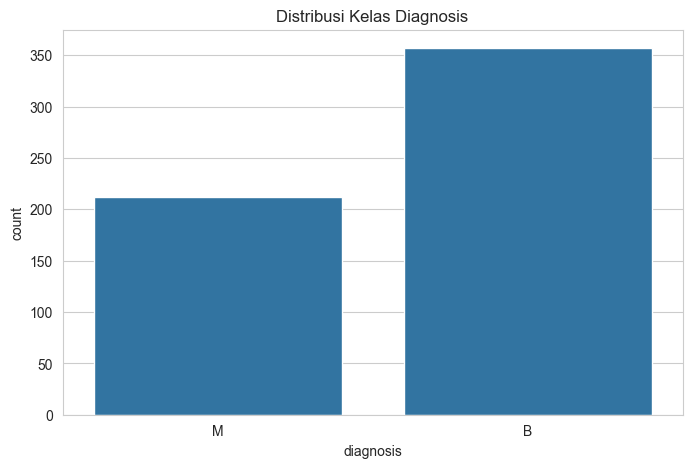

In [30]:
sns.countplot(data=df, x="diagnosis")
plt.title("Distribusi Kelas Diagnosis")
plt.show()

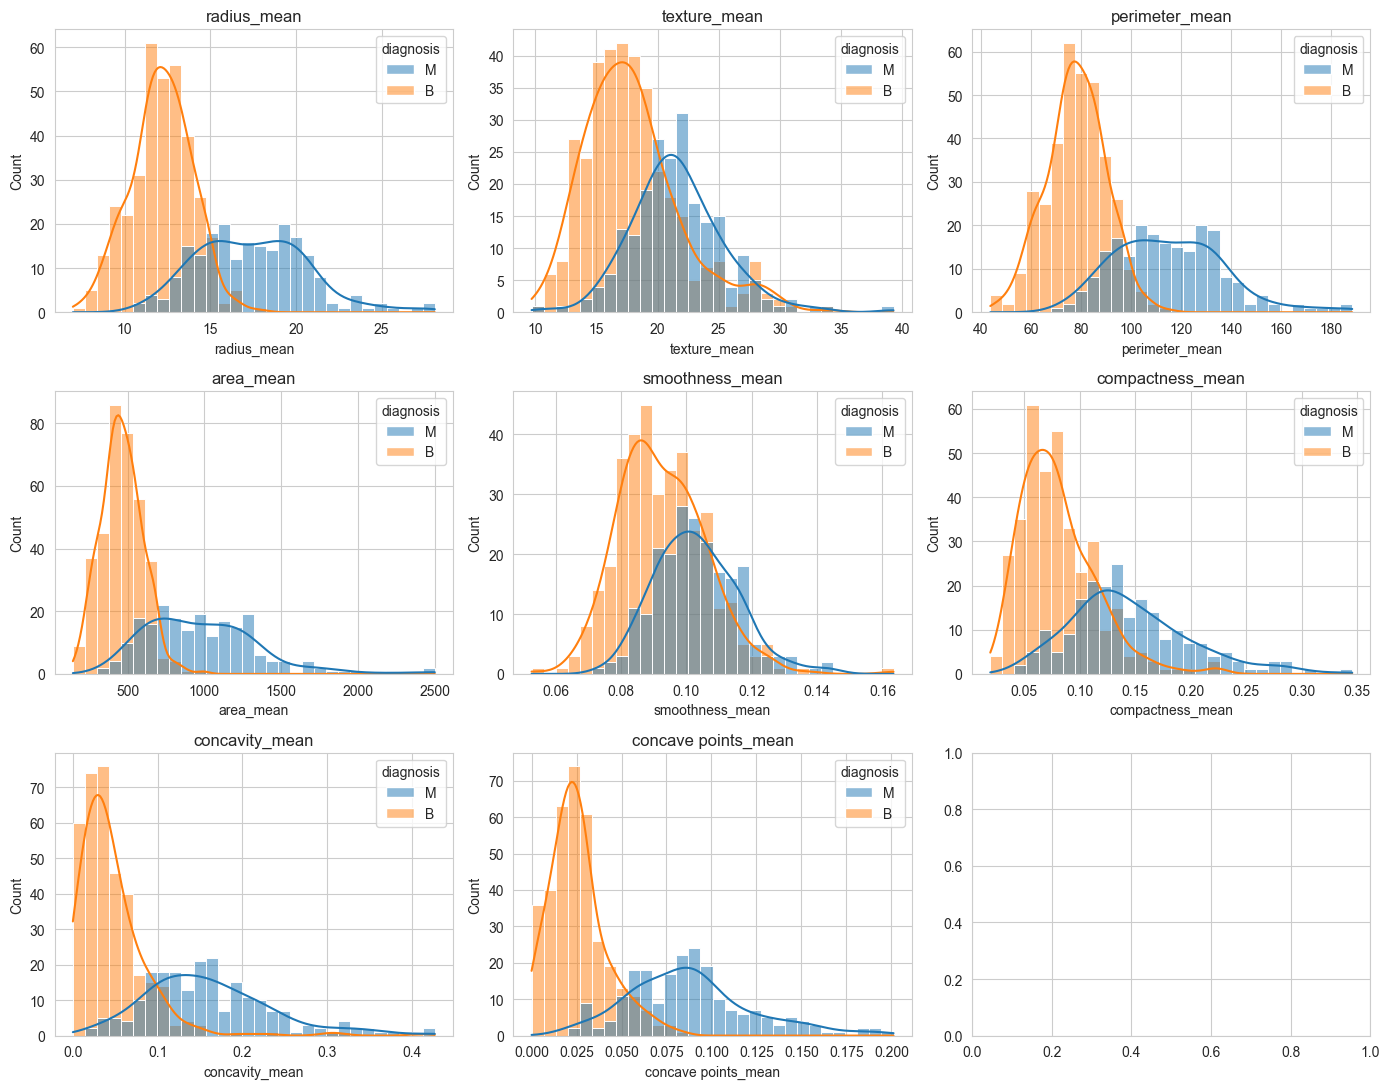

In [31]:
features = df.columns.drop(["id", "diagnosis"])

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(data=df, x=col, hue="diagnosis", kde=True, ax=ax, bins=30)
    ax.set_title(col)
plt.tight_layout()
plt.show()

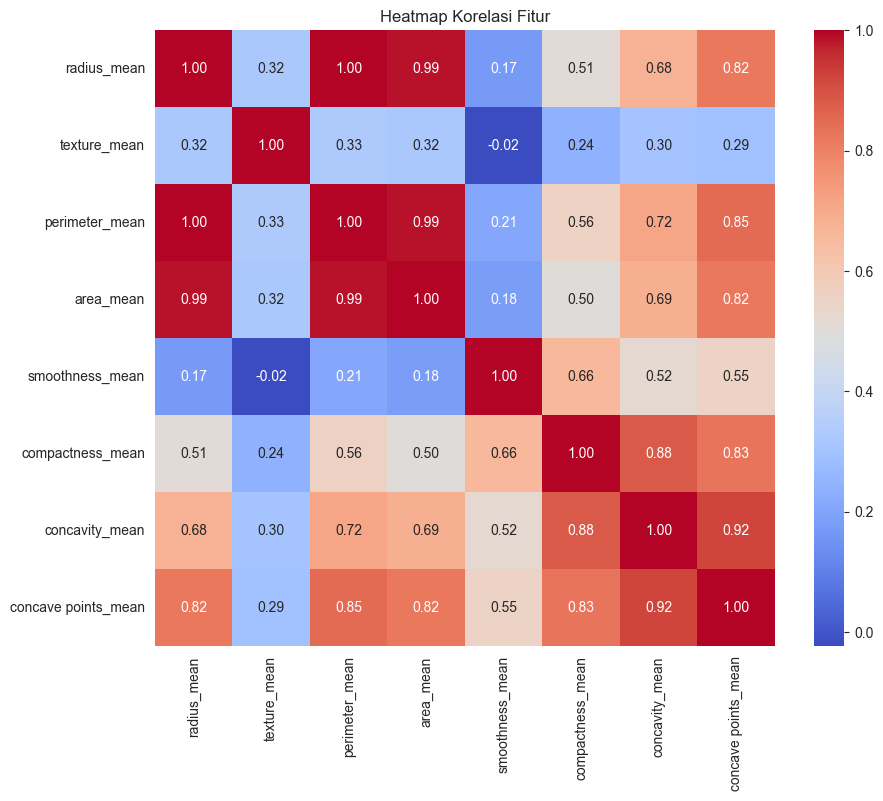

In [32]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Fitur")
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [33]:
df.isnull().sum()

id                     0
diagnosis              0
radius_mean            0
texture_mean           0
perimeter_mean         0
area_mean              0
smoothness_mean        0
compactness_mean       0
concavity_mean         0
concave points_mean    0
dtype: int64

In [34]:
df = df.drop(columns=["id"])

In [35]:
df["diagnosis"] = df["diagnosis"].map({"B": 0, "M": 1})
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [36]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Distribusi y_train:")
print(y_train.value_counts(normalize=True))

Train: (455, 8) | Test: (114, 8)
Distribusi y_train:
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64


In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("NaN di X_train:", np.isnan(X_train_scaled).sum())
print("NaN di X_test :", np.isnan(X_test_scaled).sum())

NaN di X_train: 0
NaN di X_test : 0


# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [38]:
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)

print("Akurasi Train:", round(svm_linear.score(X_train_scaled, y_train), 4))
print("Akurasi Test :", round(svm_linear.score(X_test_scaled, y_test), 4))

Akurasi Train: 0.9495
Akurasi Test : 0.9298


In [39]:
print("Jumlah support vectors (Linear):", svm_linear.n_support_.sum())

Jumlah support vectors (Linear): 69


## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [40]:
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

print("Akurasi Train:", round(svm_rbf.score(X_train_scaled, y_train), 4))
print("Akurasi Test :", round(svm_rbf.score(X_test_scaled, y_test), 4))

Akurasi Train: 0.9604
Akurasi Test : 0.9649


In [41]:
print("Jumlah support vectors (RBF):", svm_rbf.n_support_.sum())

Jumlah support vectors (RBF): 102


## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [44]:
df_C = pd.DataFrame(results_C).T
df_C = df_C.drop(columns=["model"])
df_C.columns = ["Akurasi Train", "Akurasi Test"]
df_C

,Akurasi Train,Akurasi Test
0.01,0.762637,0.789474
0.10,0.938462,0.921053
1.00,0.96044,0.964912
10.00,0.973626,0.964912
100.00,0.98022,0.929825


In [45]:
C_values = [0.01, 0.1, 1, 10, 100]
results_C = {}

for C in C_values:
    model = SVC(kernel="rbf", C=C, gamma="scale", random_state=42)
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    results_C[C] = {"train": train_acc, "test": test_acc, "model": model}

df_C = pd.DataFrame(results_C).T
df_C.columns = ["Akurasi Train", "Akurasi Test"]
df_C

ValueError: Length mismatch: Expected axis has 3 elements, new values have 2 elements

In [ ]:
plt.plot(df_C.index, df_C["Akurasi Train"], marker="o", label="Train")
plt.plot(df_C.index, df_C["Akurasi Test"], marker="s", label="Test")
plt.xscale("log")
plt.xlabel("Nilai C (log scale)")
plt.ylabel("Akurasi")
plt.title("Akurasi Train vs Test terhadap Nilai C (Kernel RBF)")
plt.legend()
plt.ylim(0.85, 1.02)
plt.show()

In [ ]:
gamma_values = [0.001, 0.01, 0.1, 1, 10]
results_gamma = {}

for g in gamma_values:
    model = SVC(kernel="rbf", C=1.0, gamma=g, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    results_gamma[g] = {"train": train_acc, "test": test_acc}

df_gamma = pd.DataFrame(results_gamma).T
df_gamma.columns = ["Akurasi Train", "Akurasi Test"]
df_gamma

In [ ]:
plt.plot(df_gamma.index, df_gamma["Akurasi Train"], marker="o", label="Train")
plt.plot(df_gamma.index, df_gamma["Akurasi Test"], marker="s", label="Test")
plt.xscale("log")
plt.xlabel("Nilai gamma (log scale)")
plt.ylabel("Akurasi")
plt.title("Akurasi Train vs Test terhadap Nilai gamma (Kernel RBF, C=1)")
plt.legend()
plt.ylim(0.85, 1.02)
plt.show()

# 4. Evaluasi Model

In [ ]:
def eval_metrics(model, X, y, name):
    y_pred = model.predict(X)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1-Score": f1_score(y, y_pred),
    }

df_eval = pd.DataFrame([
    eval_metrics(svm_linear, X_test_scaled, y_test, "Linear (C=1)"),
    eval_metrics(svm_rbf,    X_test_scaled, y_test, "RBF (C=1, gamma=scale)"),
]).set_index("Model").round(4)

df_eval

In [ ]:
cm_linear = confusion_matrix(y_test, y_pred_linear)
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm_linear, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["B", "M"], yticklabels=["B", "M"])
axes[0].set_title("Confusion Matrix - Linear")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_rbf, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["B", "M"], yticklabels=["B", "M"])
axes[1].set_title("Confusion Matrix - RBF")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [ ]:
print("Linear - jumlah support vectors:", svm_linear.n_support_.sum())
print("Linear - per kelas:", svm_linear.n_support_)
print()
print("RBF - jumlah support vectors:", svm_rbf.n_support_.sum())
print("RBF - per kelas:", svm_rbf.n_support_)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train_scaled)

best_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
best_model.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                    np.linspace(y_min, y_max, 300))

Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
            c=y_train, cmap="coolwarm", edgecolors="k", s=30)
plt.scatter(best_model.support_vectors_[:, 0],
            best_model.support_vectors_[:, 1],
            s=100, facecolors="none", edgecolors="k", label="Support Vectors")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Decision Boundary (RBF) pada Ruang PCA 2D")
plt.legend()
plt.show()

In [ ]:
print("=== Linear ===")
print(classification_report(y_test, y_pred_linear, target_names=["B", "M"]))

print("=== RBF ===")
print(classification_report(y_test, y_pred_rbf, target_names=["B", "M"]))

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.